# Feature Engineering

### Configuration

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
from pathlib import Path

IN_DIR      = Path('../data/processed/keypoints_normalized_corrected')
IN_DIR_COMB = Path('../data/processed/keypoints_corrected')

TIME_DICT = {
  '028': (9.90, 10.40, 10.50, 11.12, 11.19, 11.77),
  '030': (5.80, 6.25, 6.32,  6.70,  6.76,  7.63),
  '045': (6.54, 6.70, 6.70,  7.29,  7.45,  7.98),
  '047': (7.03, 7.41, 7.49,  7.79,  7.97,  8.91),
  '059': (6.65, 6.88, 6.90,  7.96,  8.19,  9.11),
  '061': (7.00, 7.40, 7.45,  8.10,  8.20,  9.00),
  '074': (6.07, 6.33, 6.35,  6.71,  6.90,  7.27),
  '076': (5.20, 5.80, 5.90,  6.30,  6.40,  7.30),
  '091': (6.39, 6.55, 6.60,  7.03,  7.18,  7.61),
  '093': (5.86, 6.10, 6.20,  6.65,  6.85,  7.67),
}

## Utgångsposition

In [13]:
def get_phase(df, t_start, t_end):
    return df[(df['time'] >= t_start) & (df['time'] <= t_end)].reset_index(drop=True)

def xy(df, joint):
    return df[[f'{joint}_x', f'{joint}_y']].values

def compute_angle(A, B, C):
    BA = A - B
    BC = C - B
    dot  = (BA * BC).sum(axis=1)
    norm = np.linalg.norm(BA, axis=1) * np.linalg.norm(BC, axis=1)
    return np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))

In [14]:
def extract_utgångsposition(df):
    ls, rs = xy(df, 'left_shoulder'), xy(df, 'right_shoulder')
    lh, rh = xy(df, 'left_hip'),      xy(df, 'right_hip')
    lk, rk = xy(df, 'left_knee'),     xy(df, 'right_knee')
    la, ra = xy(df, 'left_ankle'),     xy(df, 'right_ankle')
    nose   = xy(df, 'nose')

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk)
    right_hip_a  = compute_angle(rs, rh, rk)

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_vec    = mid_shoulder - mid_hip
    vertical     = np.array([0, -1])
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    return {
        'mean_left_knee_angle':  left_knee_a.mean(),
        'mean_right_knee_angle': right_knee_a.mean(),
        'delta_knee_angle':      np.abs(left_knee_a - right_knee_a).mean(),
        'mean_left_hip_angle':   left_hip_a.mean(),
        'mean_right_hip_angle':  right_hip_a.mean(),
        'delta_hip_angle':       np.abs(left_hip_a - right_hip_a).mean(),
        'mean_trunk_angle':      trunk_a.mean(),
        'mean_head_trunk_angle': head_trunk_a.mean(),
        'delta_hip_height':      np.abs(lh[:, 1] - rh[:, 1]).mean(),
    }

In [15]:
OUT_DIR = Path('../data/processed/features')
OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for vid_id, times in TIME_DICT.items():
    t0, t1 = times[0], times[1]
    df = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    phase = get_phase(df, t0, t1)
    rows.append({'video': vid_id, **extract_utgångsposition(phase)})

df_utgång = pd.DataFrame(rows).set_index('video')
df_utgång.to_csv(OUT_DIR / 'utgångsposition.csv')
display(df_utgång.round(2))

,mean_left_knee_angle,mean_right_knee_angle,delta_knee_angle,mean_left_hip_angle,mean_right_hip_angle,delta_hip_angle,mean_trunk_angle,mean_head_trunk_angle,delta_hip_height
video,,,,,,,,,
028,121.08,110.50,10.58,133.05,122.54,10.51,6.42,159.72,0.08
030,111.70,102.16,9.53,120.34,109.23,11.11,0.34,161.28,0.03
045,123.38,118.73,4.66,133.32,124.69,8.63,5.69,157.61,0.03
047,111.52,107.05,4.46,114.45,105.33,9.12,4.00,164.16,0.04
059,115.61,119.46,3.86,130.97,135.17,4.20,9.01,156.83,0.12
061,112.23,108.89,3.34,115.77,110.75,5.02,3.78,165.01,0.01
074,94.97,98.26,3.29,111.04,109.55,1.49,5.35,157.99,0.10
076,112.21,105.26,6.95,119.44,108.65,10.79,3.34,164.01,0.06
091,111.30,114.65,3.35,121.76,129.37,7.61,9.42,161.39,0.23


## Förberedelsefas

In [16]:
def extract_förberedelsefas(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    nose   = xy(df_norm, 'nose')
    lw, rw = xy(df_norm, 'left_wrist'),    xy(df_norm, 'right_wrist')

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2

    vertical  = np.array([0, -1])
    trunk_vec = mid_shoulder - mid_hip
    trunk_a   = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    dt           = 1 / 50
    velocity     = np.diff(trunk_a) / dt
    acceleration = np.diff(velocity) / dt

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_x   = ((lh_c + rh_c) / 2)[:, 0]

    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    lw_acc = np.diff(np.diff(lw, axis=0) / dt, axis=0) / dt
    rw_acc = np.diff(np.diff(rw, axis=0) / dt, axis=0) / dt
    rms_wrist = (np.sqrt(np.mean(np.linalg.norm(lw_acc, axis=1) ** 2)) +
                 np.sqrt(np.mean(np.linalg.norm(rw_acc, axis=1) ** 2))) / 2

    return {
        'forb_delta_trunk_flexion':          trunk_a.max() - trunk_a[0],
        'forb_max_trunk_angular_velocity':   np.abs(velocity).max(),
        'forb_trunk_hip_correlation':        np.corrcoef(trunk_a, mid_hip_x)[0, 1],
        'forb_rms_trunk_acceleration':       np.sqrt(np.mean(acceleration ** 2)),
        'forb_mean_head_trunk_angle':        head_trunk_a.mean(),
        'forb_rms_wrist_acceleration':       rms_wrist,
    }

In [17]:
rows = []
for vid_id, times in TIME_DICT.items():
    t1, t3 = times[1], times[3]
    if t3 is None:
        continue
    df_norm = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_norm = get_phase(df_norm, t1, t3)
    phase_comb = get_phase(df_comb, t1, t3)
    rows.append({'video': vid_id, **extract_förberedelsefas(phase_norm, phase_comb)})

df_förb = pd.DataFrame(rows).set_index('video')
df_förb.to_csv(OUT_DIR / 'förberedelsefas.csv')
display(df_förb.round(4))

,forb_delta_trunk_flexion,forb_max_trunk_angular_velocity,forb_trunk_hip_correlation,forb_rms_trunk_acceleration,forb_mean_head_trunk_angle,forb_rms_wrist_acceleration
video,,,,,,
028,8.9712,78.6070,-0.7599,712.2466,157.2450,31.6808
030,15.0717,60.9344,0.1145,263.5966,156.2739,37.4504
045,6.8785,77.3474,-0.6413,1033.9616,152.1420,20.7276
047,13.6644,64.4836,0.6867,449.6918,164.0812,37.9827
059,7.6745,72.5936,-0.8474,769.5677,150.1699,34.8328
061,15.5173,58.8260,-0.1230,569.9785,166.2739,30.8217
074,3.4749,73.5604,-0.2317,975.6025,160.7467,38.3646
076,15.2447,106.8671,-0.8695,631.2522,164.3567,18.5547
091,0.0000,74.7253,0.5846,1155.7418,152.0202,23.7994


## Uppresningsfas

In [18]:
def extract_uppresningsfas(df_norm):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),     xy(df_norm, 'right_knee')
    la, ra = xy(df_norm, 'left_ankle'),     xy(df_norm, 'right_ankle')

    knee_a = (compute_angle(lh, lk, la) + compute_angle(rh, rk, ra)) / 2
    hip_a  = (compute_angle(ls, lh, lk) + compute_angle(rs, rh, rk)) / 2

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    vertical     = np.array([0, -1])
    trunk_vec    = mid_shoulder - mid_hip
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    dt        = 1 / 50
    knee_vel  = np.diff(knee_a) / dt
    trunk_vel = np.diff(trunk_a) / dt
    trunk_acc = np.diff(trunk_vel) / dt

    return {
        'uppr_total_knee_extension':          knee_a[-1] - knee_a[0],
        'uppr_peak_knee_extension_velocity':  knee_vel.max(),
        'uppr_total_hip_extension':           hip_a[-1] - hip_a[0],
        'uppr_trunk_reextension_angle':       trunk_a[0] - trunk_a[-1],
        'uppr_rms_trunk_acceleration':        np.sqrt(np.mean(trunk_acc ** 2)),
    }

In [19]:
rows = []
for vid_id, times in TIME_DICT.items():
    t4, t5 = times[4], times[5]
    if t4 is None:
        continue
    df_norm = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    phase_norm = get_phase(df_norm, t4, t5)
    rows.append({'video': vid_id, **extract_uppresningsfas(phase_norm)})

df_uppr = pd.DataFrame(rows).set_index('video')
df_uppr.to_csv(OUT_DIR / 'uppresningsfas.csv')
display(df_uppr.round(4))

,uppr_total_knee_extension,uppr_peak_knee_extension_velocity,uppr_total_hip_extension,uppr_trunk_reextension_angle,uppr_rms_trunk_acceleration
video,,,,,
028,43.5211,167.2711,58.7040,18.1063,1561.2170
030,62.5380,137.6310,71.4366,19.8333,874.8655
045,28.0530,146.1464,41.8746,15.0440,840.5068
047,47.2575,151.1972,71.5267,27.4716,663.0849
059,35.4561,90.3963,61.5670,28.8408,629.7482
061,39.1547,101.5488,58.1804,20.8465,463.0879
074,53.2385,211.3980,57.9133,13.1911,866.3877
076,55.1630,145.1928,68.7083,21.8699,811.7044
091,46.9134,184.6739,52.8183,10.5145,1006.2878


## Plots

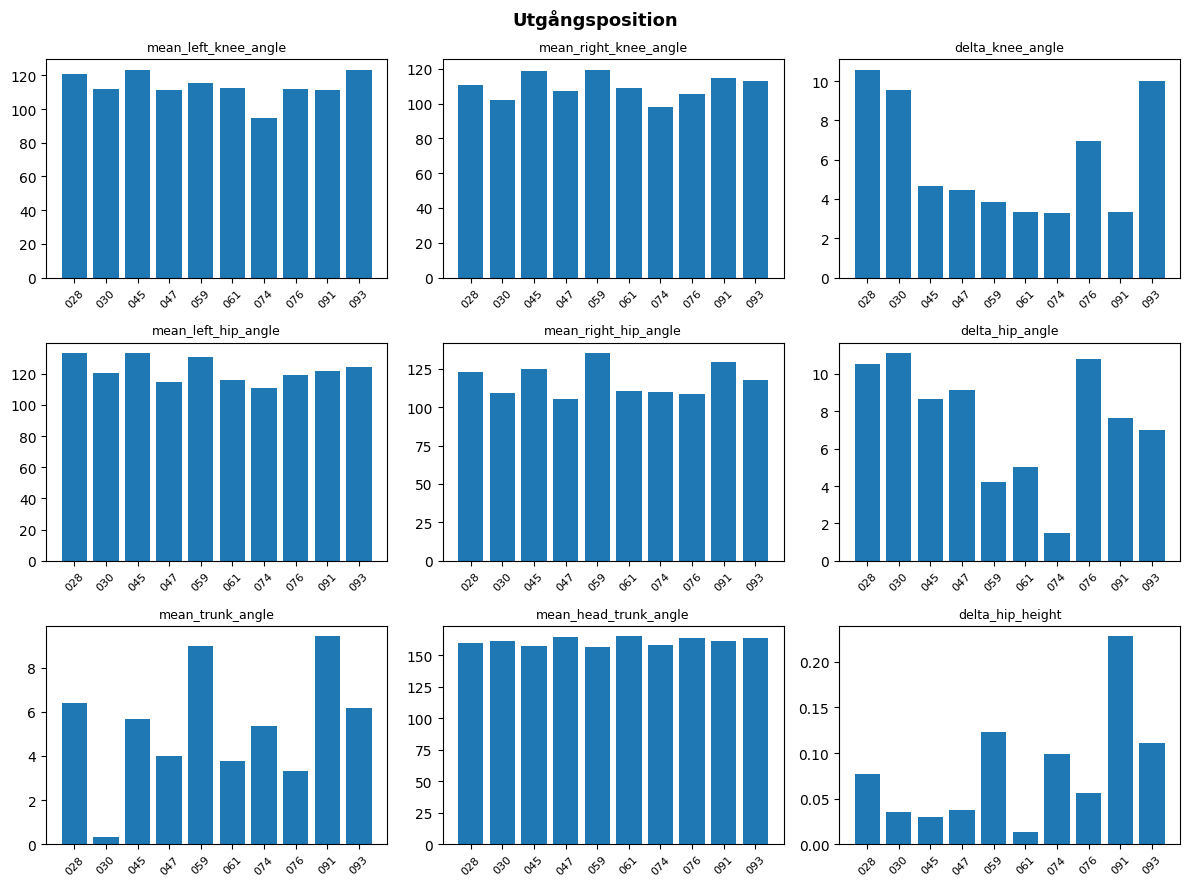

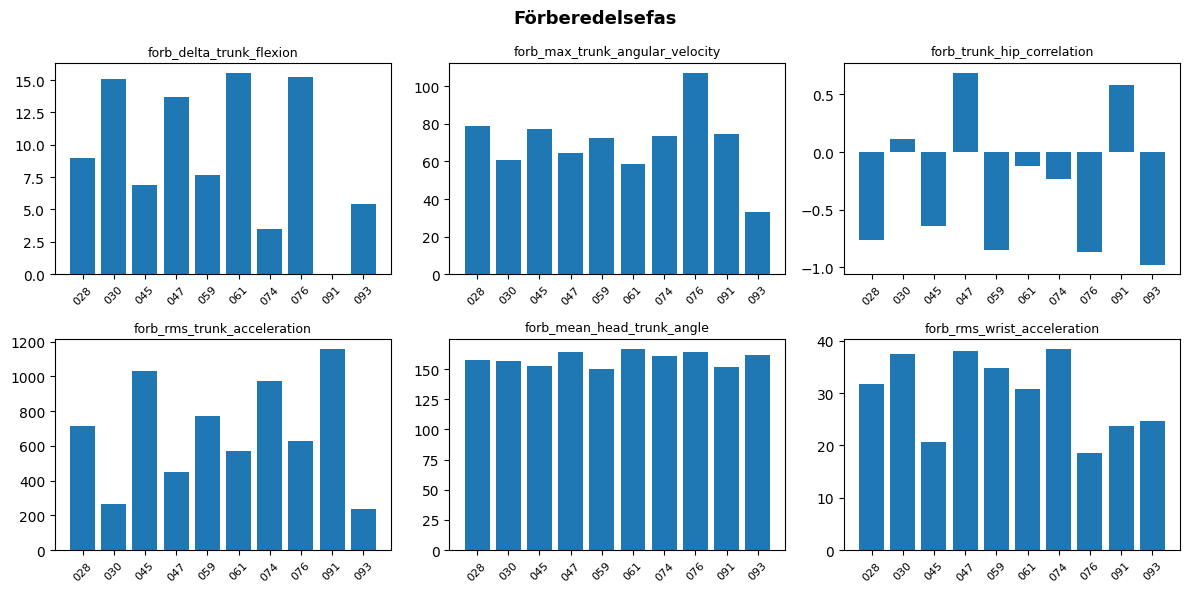

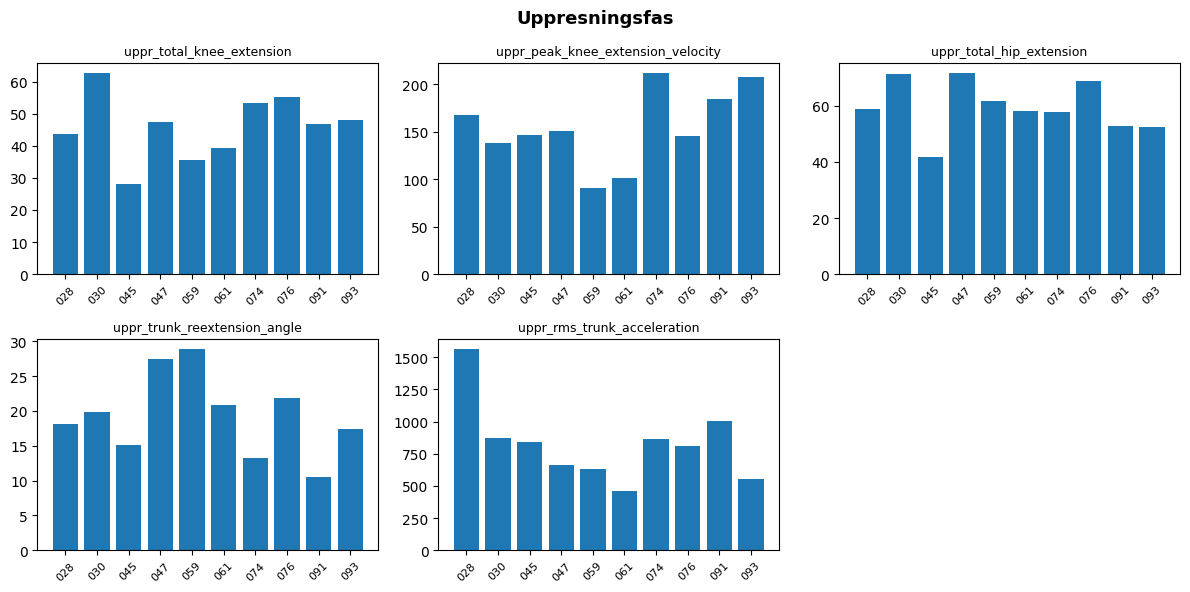

In [20]:
def plot_phase(df, title, ncols, filepath):
    features = df.columns.tolist()
    nrows = (len(features) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
    for i, feat in enumerate(features):
        axes[i].bar(df.index, df[feat])
        axes[i].set_title(feat, fontsize=9)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(filepath, dpi=150)
    plt.show()

plot_phase(df_utgång, 'Utgångsposition', ncols=3, filepath=OUT_DIR / 'utgångsposition.png')

# Förberedelsefas
forb_cols = [c for c in df_förb.columns if c.startswith('forb_')]
plot_phase(df_förb[forb_cols], 'Förberedelsefas', ncols=3, filepath=OUT_DIR / 'förberedelsefas.png')

# Uppresningsfas
uppr_cols = [c for c in df_uppr.columns if c.startswith('uppr_')]
plot_phase(df_uppr[uppr_cols], 'Uppresningsfas', ncols=3, filepath=OUT_DIR / 'uppresningsfas.png')

## MoLab Features

In [21]:
from pathlib import Path
import pandas as pd

MOLAB_FULL_DIR    = Path('../data/processed/molab')
MOLAB_CROPPED_DIR = Path('../data/processed/molab_cropped')

JOINT_ANGLE_COLS = [c for c in pd.read_csv(MOLAB_CROPPED_DIR / '0028_molab.csv', nrows=0).columns
                    if c.startswith('JointAngle/')]

offsets = {}
for vid in TIME_DICT:
    full = pd.read_csv(MOLAB_FULL_DIR / f'0{vid}_molab.csv')
    pre  = full[full['molab_frame'] < 41]
    offsets[vid] = pre[JOINT_ANGLE_COLS].mean()

display_cols = ['JointAngle/L_knee_X', 'JointAngle/R_knee_X',
                'JointAngle/L_hip_X',  'JointAngle/R_hip_X',
                'JointAngle/pelvis_X', 'JointAngle/pelvis_Y']
offset_df = pd.DataFrame(offsets).T[display_cols].round(1)
offset_df.columns = ['L_knee', 'R_knee', 'L_hip', 'R_hip', 'pelvis_X', 'pelvis_Y']
print("Pre-calibration offsets (absolute joint angles while seated, degrees):")
display(offset_df)

molab_corrected = {}
for vid in TIME_DICT:
    cropped = pd.read_csv(MOLAB_CROPPED_DIR / f'0{vid}_molab.csv')
    corrected = cropped.copy()
    corrected[JOINT_ANGLE_COLS] = cropped[JOINT_ANGLE_COLS] + offsets[vid]
    molab_corrected[vid] = corrected

print(f"\nmolab_corrected: dict with {len(molab_corrected)} videos, ready for feature engineering.")
print("Non-JointAngle columns (gyro, acc) are unchanged.")

Pre-calibration offsets (absolute joint angles while seated, degrees):


,L_knee,R_knee,L_hip,R_hip,pelvis_X,pelvis_Y
028,92.9,95.9,46.3,50.9,-25.6,-0.3
030,98.2,101.7,83.5,89.4,11.8,-3.0
045,82.5,80.2,55.0,57.4,-11.7,-4.9
047,90.4,89.5,95.1,100.7,28.2,0.0
059,95.5,86.3,46.3,46.0,-21.4,-2.7
061,96.8,90.3,76.6,76.2,9.6,-3.3
074,104.8,97.9,71.5,71.2,-2.4,1.4
076,104.8,99.3,99.9,100.0,26.1,1.4
091,83.1,81.0,37.9,43.1,-29.1,-0.4
093,91.7,91.9,97.0,102.7,33.6,-1.1



molab_corrected: dict with 10 videos, ready for feature engineering.
Non-JointAngle columns (gyro, acc) are unchanged.


In [22]:
import numpy as np

def molab_phase(df, t_start, t_end):
    return df[(df['video_time'] >= t_start) & (df['video_time'] <= t_end)]

def rms(x):
    return np.sqrt(np.mean(x ** 2))

def molab_extract_utgångsposition(df, t0, t1):
    p = molab_phase(df, t0, t1)
    lk = p['JointAngle/L_knee_X']
    rk = p['JointAngle/R_knee_X']
    return {
        'mean_L_knee_flexion':  lk.mean(),
        'mean_R_knee_flexion':  rk.mean(),
        'delta_knee_asymmetry': abs(lk.mean() - rk.mean()),
        'mean_L_hip_flexion':   p['JointAngle/L_hip_X'].mean(),
        'mean_R_hip_flexion':   p['JointAngle/R_hip_X'].mean(),
        'mean_pelvis_tilt':     p['JointAngle/pelvis_X'].mean(),
        'mean_pelvis_lateral':  p['JointAngle/pelvis_Y'].abs().mean(),
    }

def molab_extract_rörelsestart(df, t1, t5):
    p = molab_phase(df, t1, t5)
    pelvis_x = p['JointAngle/pelvis_X']
    gyro_x   = p['SegmentGyro/pelvis_X']
    return {
        'initial_pelvis_tilt': pelvis_x.iloc[0] if len(pelvis_x) else np.nan,
        'max_pelvis_tilt':     pelvis_x.max(),
        'delta_pelvis_tilt':   pelvis_x.max() - pelvis_x.min(),
        'peak_pelvis_gyro':    gyro_x.abs().max(),
        'mean_pelvis_gyro':    gyro_x.abs().mean(),
        'hip_flexion_range':   ((p['JointAngle/L_hip_X'].max() - p['JointAngle/L_hip_X'].min()) +
                                (p['JointAngle/R_hip_X'].max() - p['JointAngle/R_hip_X'].min())) / 2,
        'rms_pelvis_acc':      rms(p['SegmentAcc/pelvis_Y'].values),
    }

def molab_extract_rörelseutförande(df, t2, t3, t4, t5):
    forb = molab_phase(df, t2, t3)
    uppr = molab_phase(df, t4, t5)
    lk_up, rk_up = uppr['JointAngle/L_knee_X'], uppr['JointAngle/R_knee_X']
    return {
        'forb_delta_pelvis_tilt':    forb['JointAngle/pelvis_X'].max() - forb['JointAngle/pelvis_X'].min(),
        'forb_peak_pelvis_gyro':     forb['SegmentGyro/pelvis_X'].abs().max(),
        'forb_rms_pelvis_acc':       rms(forb['SegmentAcc/pelvis_Y'].values),
        'uppr_total_knee_extension': ((lk_up.max() - lk_up.min()) + (rk_up.max() - rk_up.min())) / 2,
        'uppr_peak_shank_gyro':      max(uppr['SegmentGyro/L_shank_X'].abs().max(),
                                         uppr['SegmentGyro/R_shank_X'].abs().max()),
        'uppr_total_hip_extension':  ((uppr['JointAngle/L_hip_X'].max() - uppr['JointAngle/L_hip_X'].min()) +
                                      (uppr['JointAngle/R_hip_X'].max() - uppr['JointAngle/R_hip_X'].min())) / 2,
    }

In [23]:
rows_utg, rows_rs, rows_ru = [], [], []

for vid, (t0, t1, t2, t3, t4, t5) in TIME_DICT.items():
    df = molab_corrected[vid]
    rows_utg.append({'video': vid, **molab_extract_utgångsposition(df, t0, t1)})
    rows_rs.append( {'video': vid, **molab_extract_rörelsestart(df, t1, t5)})
    rows_ru.append( {'video': vid, **molab_extract_rörelseutförande(df, t2, t3, t4, t5)})

OUT_DIR = Path('../data/processed/features')

df_molab_utg = pd.DataFrame(rows_utg).set_index('video')
df_molab_rs  = pd.DataFrame(rows_rs).set_index('video')
df_molab_ru  = pd.DataFrame(rows_ru).set_index('video')

df_molab_utg.to_csv(OUT_DIR / 'molab_utgångsposition.csv')
df_molab_rs.to_csv(OUT_DIR  / 'molab_rörelsestart.csv')
df_molab_ru.to_csv(OUT_DIR  / 'molab_rörelseutförande.csv')

print("=== Utgångsposition ==="); display(df_molab_utg.round(2))
print("=== Rörelsestart ===");    display(df_molab_rs.round(2))
print("=== Rörelseutförande ==="); display(df_molab_ru.round(2))

=== Utgångsposition ===


,mean_L_knee_flexion,mean_R_knee_flexion,delta_knee_asymmetry,mean_L_hip_flexion,mean_R_hip_flexion,mean_pelvis_tilt,mean_pelvis_lateral
video,,,,,,,
028,92.87,95.95,3.08,46.35,50.94,-25.65,0.34
030,98.40,101.82,3.41,83.65,89.58,11.77,2.83
045,82.48,80.16,2.32,55.07,57.42,-11.61,4.83
047,90.61,89.62,0.98,95.26,101.03,28.56,0.06
059,95.51,86.23,9.28,45.83,45.41,-21.78,2.50
061,98.95,92.27,6.68,78.76,78.01,9.37,3.43
074,105.55,97.87,7.68,72.11,70.95,-3.08,1.50
076,104.90,99.44,5.46,100.11,100.33,26.31,1.36
091,82.75,80.99,1.76,37.75,43.01,-28.95,0.34


=== Rörelsestart ===


,initial_pelvis_tilt,max_pelvis_tilt,delta_pelvis_tilt,peak_pelvis_gyro,mean_pelvis_gyro,hip_flexion_range,rms_pelvis_acc
video,,,,,,,
028,-25.61,32.92,58.53,234.17,70.04,97.61,0.59
030,11.36,53.12,42.05,127.97,62.28,117.97,0.42
045,-11.60,52.65,64.26,283.58,69.25,77.08,0.65
047,29.46,64.09,43.30,130.84,53.46,117.24,0.34
059,-21.75,38.21,60.82,137.80,32.72,79.58,0.61
061,9.52,44.18,34.66,79.80,31.13,73.71,0.37
074,-5.04,39.86,45.28,406.10,65.05,79.58,0.53
076,27.04,56.56,34.09,96.18,43.89,112.46,0.29
091,-29.57,43.81,75.07,256.18,104.40,96.48,0.73


=== Rörelseutförande ===


,forb_delta_pelvis_tilt,forb_peak_pelvis_gyro,forb_rms_pelvis_acc,uppr_total_knee_extension,uppr_peak_shank_gyro,uppr_total_hip_extension
video,,,,,,
028,46.73,234.17,0.37,82.36,39.43,96.05
030,21.22,115.89,0.12,96.11,34.06,117.97
045,46.68,283.58,0.24,58.88,33.66,74.86
047,20.66,130.84,0.17,78.66,38.88,111.67
059,43.16,137.80,0.21,80.15,35.10,75.25
061,19.66,79.80,0.12,75.59,31.95,73.71
074,35.46,406.10,0.27,78.85,109.41,67.46
076,23.61,96.18,0.23,87.41,45.48,110.20
091,53.05,226.99,0.30,77.65,89.88,94.02


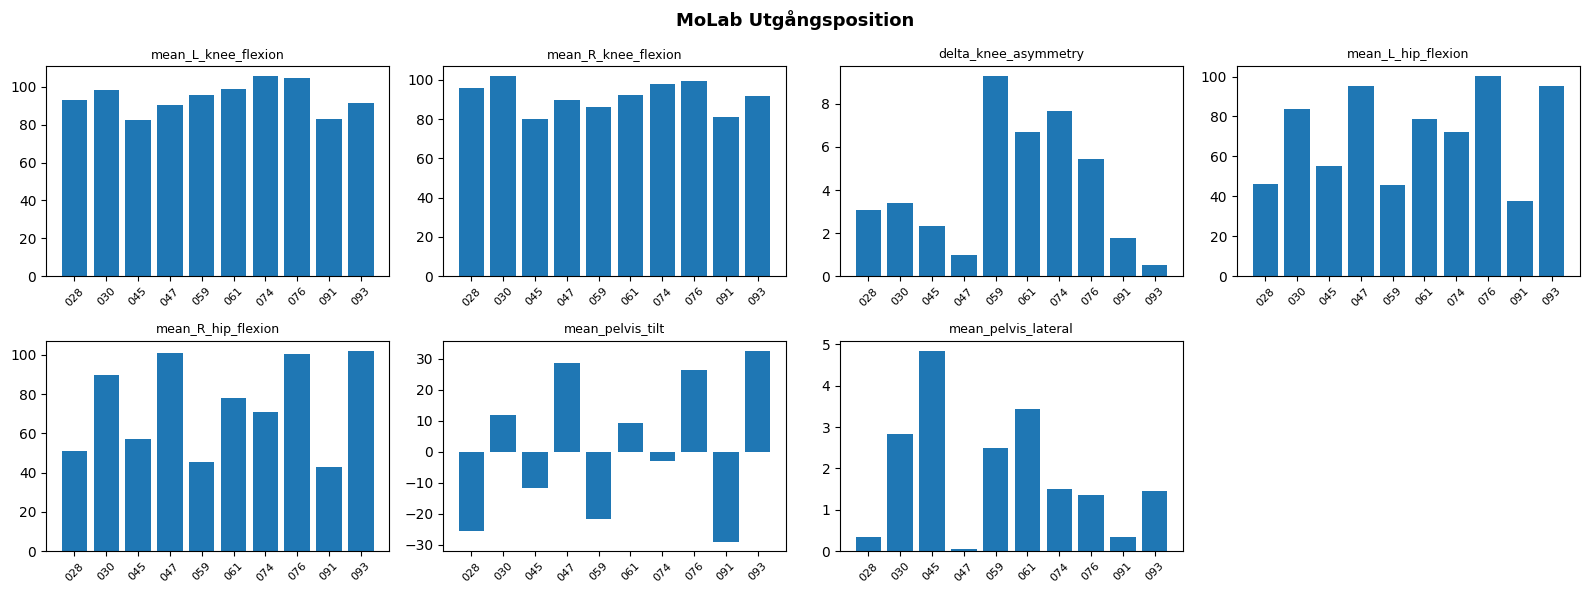

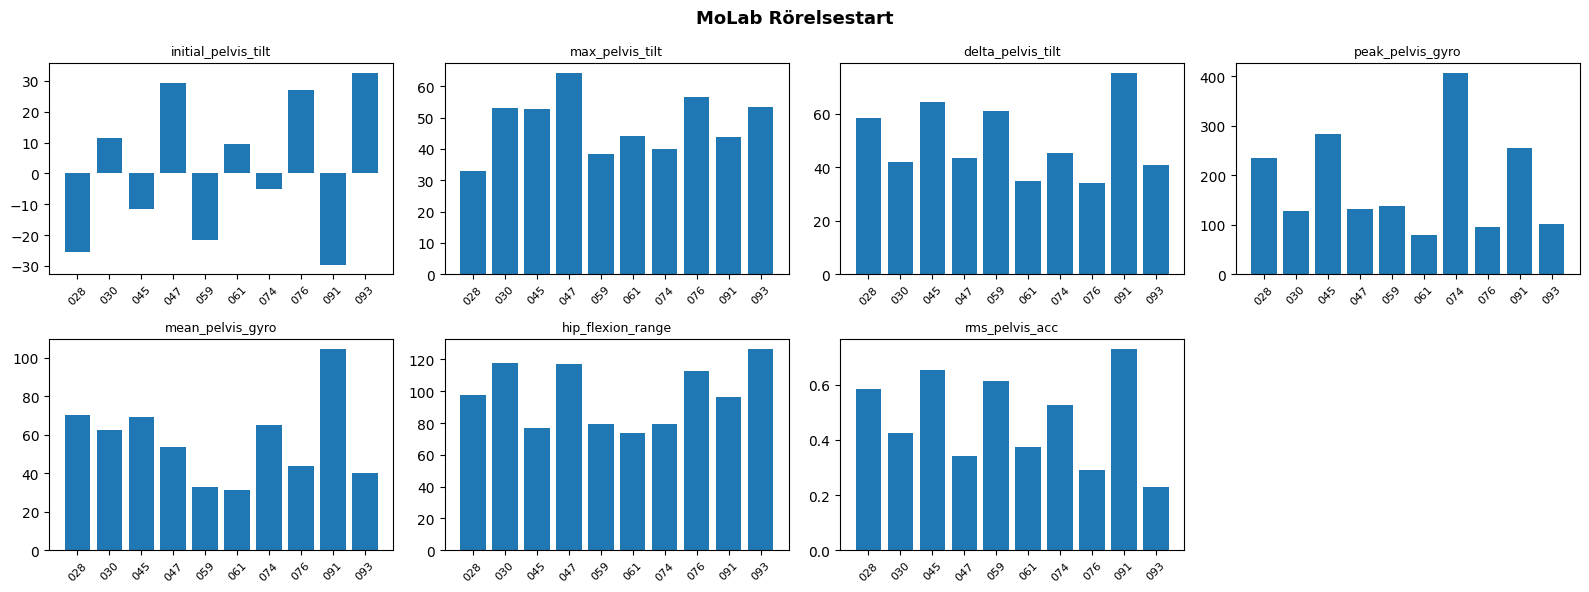

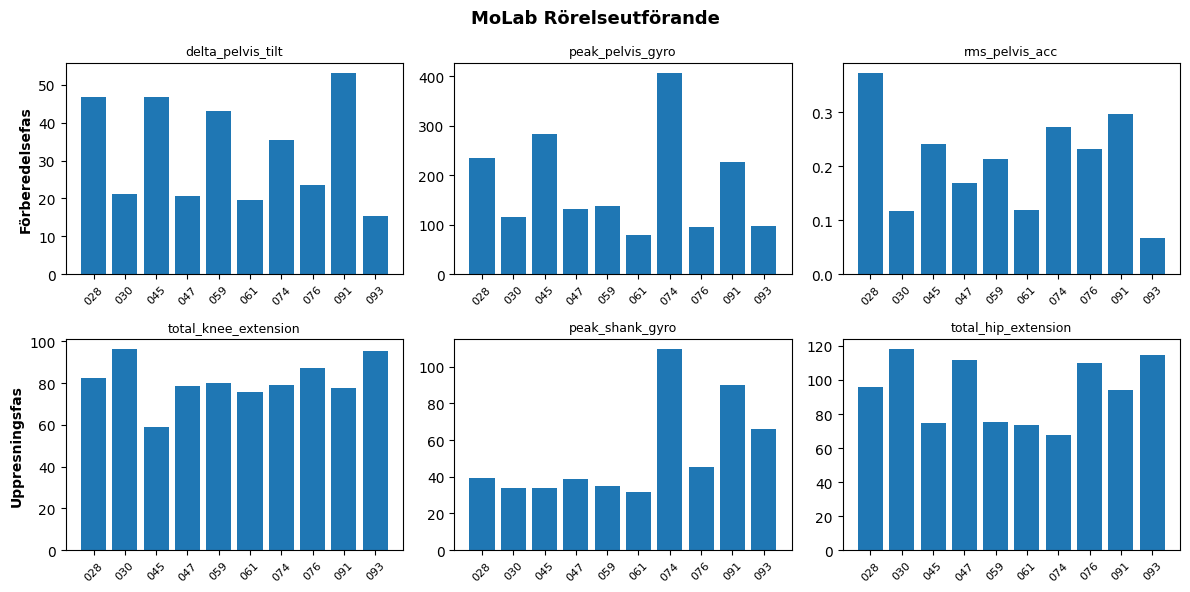

In [24]:
forb_cols = [c for c in df_molab_ru.columns if c.startswith('forb_')]
uppr_cols = [c for c in df_molab_ru.columns if c.startswith('uppr_')]
ncols_ru  = max(len(forb_cols), len(uppr_cols))

plot_phase(df_molab_utg, 'MoLab Utgångsposition', ncols=4, filepath=OUT_DIR / 'molab_utgångsposition.png')
plot_phase(df_molab_rs,  'MoLab Rörelsestart',    ncols=4, filepath=OUT_DIR / 'molab_rörelsestart.png')

fig, axes = plt.subplots(2, ncols_ru, figsize=(4 * ncols_ru, 6))
for i, feat in enumerate(forb_cols):
    axes[0, i].bar(df_molab_ru.index, df_molab_ru[feat])
    axes[0, i].set_title(feat.replace('forb_', ''), fontsize=9)
    axes[0, i].tick_params(axis='x', rotation=45, labelsize=8)
for i, feat in enumerate(uppr_cols):
    axes[1, i].bar(df_molab_ru.index, df_molab_ru[feat])
    axes[1, i].set_title(feat.replace('uppr_', ''), fontsize=9)
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=8)
for j in range(len(uppr_cols), ncols_ru):
    axes[1, j].set_visible(False)
axes[0, 0].set_ylabel('Förberedelsefas', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Uppresningsfas',  fontsize=10, fontweight='bold')
fig.suptitle('MoLab Rörelseutförande', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'molab_rörelseutförande.png', dpi=150)
plt.show()

# Stand to sit

In [25]:
DOWN_TIME_DICT = {
  '028': (11.87, 11.90, 11.90, 12.57, 12.82),
  '030': (8.07, 9.62, 9.62, 10.64, 11.16),
  '045': (7.94, 7.96, 7.96, 8.74, 9.26),
  '047': (9.20, 10.14, 10.14, 11.10, 11.70),
  '059': (9.11, 9.18, 9.18, 10.37, 11.06),
  '061': (10.57, 10.88, 10.88, 12.26, 13.00),
  '074': (7.27, 7.30, 7.30, 7.88, 8.14),
  '076': (8.27, 8.72, 8.72, 9.73, 10.32),
  '091': (7.56, 7.58, 7.58, 8.09, 8.18),
  '093': (8.50, 9.19, 9.19, 10.08, 10.74),
}

In [26]:
DOWN_IN_DIR      = Path('../data/processed/keypoints_normalized_corrected_down')
DOWN_IN_DIR_COMB = Path('../data/processed/keypoints_corrected_down')
DOWN_OUT_DIR     = Path('../data/processed/features_down')
DOWN_OUT_DIR.mkdir(parents=True, exist_ok=True)

### Utgångsposition

In [27]:
def extract_utgångsposition_down(df):
    ls, rs = xy(df, 'left_shoulder'), xy(df, 'right_shoulder')
    lh, rh = xy(df, 'left_hip'),      xy(df, 'right_hip')
    lk, rk = xy(df, 'left_knee'),     xy(df, 'right_knee')
    la, ra = xy(df, 'left_ankle'),     xy(df, 'right_ankle')
    nose   = xy(df, 'nose')

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk)
    right_hip_a  = compute_angle(rs, rh, rk)

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_vec    = mid_shoulder - mid_hip
    vertical     = np.array([0, -1])
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    stance_w = np.linalg.norm(la - ra, axis=1)
    hip_w    = np.linalg.norm(lh - rh, axis=1)
    knee_fwd = ((lk[:, 0] - la[:, 0]) + (rk[:, 0] - ra[:, 0])) / 2

    return {
        'stance_width':          stance_w.mean(),
        'stance_to_hip_ratio':   (stance_w / np.clip(hip_w, 1e-6, None)).mean(),
        'mean_left_knee_angle':  left_knee_a.mean(),
        'mean_right_knee_angle': right_knee_a.mean(),
        'delta_knee_angle':      np.abs(left_knee_a - right_knee_a).mean(),
        'mean_left_hip_angle':   left_hip_a.mean(),
        'mean_right_hip_angle':  right_hip_a.mean(),
        'delta_hip_angle':       np.abs(left_hip_a - right_hip_a).mean(),
        'mean_trunk_angle':      trunk_a.mean(),
        'mean_head_trunk_angle': head_trunk_a.mean(),
        'shoulder_asym':         np.abs(ls[:, 1] - rs[:, 1]).mean(),
        'hip_asym':              np.abs(lh[:, 1] - rh[:, 1]).mean(),
        'knee_asym':             np.abs(lk[:, 1] - rk[:, 1]).mean(),
        'mean_knee_forward':     knee_fwd.mean(),
    }

In [28]:
rows = []
for vid_id, times in DOWN_TIME_DICT.items():
    t0, t1 = times[0], times[1]
    df = pd.read_csv(next(DOWN_IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    phase = get_phase(df, t0, t1)
    rows.append({'video': vid_id, **extract_utgångsposition_down(phase)})

df_down_utgång = pd.DataFrame(rows).set_index('video')
df_down_utgång.to_csv(DOWN_OUT_DIR / 'down_utgångsposition.csv')
display(df_down_utgång.round(2))

,stance_width,stance_to_hip_ratio,mean_left_knee_angle,mean_right_knee_angle,delta_knee_angle,mean_left_hip_angle,mean_right_hip_angle,delta_hip_angle,mean_trunk_angle,mean_head_trunk_angle,shoulder_asym,hip_asym,knee_asym,mean_knee_forward
video,,,,,,,,,,,,,,
028,0.14,1.18,177.56,172.17,5.38,179.70,175.90,3.80,0.61,162.22,0.01,0.01,0.04,-0.05
030,0.14,0.92,179.09,179.20,0.36,177.59,179.06,1.47,0.70,161.46,0.05,0.01,0.02,-0.04
045,0.14,0.91,169.71,173.24,3.53,164.77,166.47,1.70,7.42,163.73,0.01,0.01,0.00,-0.02
047,0.15,1.03,176.09,178.71,2.62,178.72,179.62,0.91,0.25,162.26,0.01,0.01,0.02,-0.04
059,0.11,0.81,177.41,173.94,3.47,179.84,179.40,0.44,1.33,162.83,0.02,0.00,0.05,-0.06
061,0.12,0.72,175.71,174.34,1.38,177.68,179.53,1.85,0.42,164.56,0.05,0.01,0.04,-0.06
074,0.17,1.30,174.27,174.54,0.56,175.29,173.46,1.84,2.03,168.11,0.02,0.00,0.05,-0.03
076,0.11,0.67,178.16,178.69,0.53,176.15,174.10,2.05,1.58,160.66,0.04,0.01,0.03,-0.04
091,0.16,1.12,175.56,177.64,2.08,172.48,170.62,1.87,4.54,162.50,0.01,0.01,0.03,0.01


### Nedåtgående

In [29]:
def extract_nedåtgående_down(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),     xy(df_norm, 'right_knee')
    la, ra = xy(df_norm, 'left_ankle'),     xy(df_norm, 'right_ankle')

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_vec    = mid_shoulder - mid_hip
    vertical     = np.array([0, -1])
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk)
    right_hip_a  = compute_angle(rs, rh, rk)

    knee_fwd = ((lk[:, 0] - la[:, 0]) + (rk[:, 0] - ra[:, 0])) / 2

    dt = 1 / 50
    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_c   = (lh_c + rh_c) / 2
    hip_vel_y   = np.diff(mid_hip_c[:, 1]) / dt
    hip_acc_y   = np.diff(hip_vel_y) / dt

    lk_c, rk_c = xy(df_comb, 'left_knee'), xy(df_comb, 'right_knee')
    la_c, ra_c = xy(df_comb, 'left_ankle'), xy(df_comb, 'right_ankle')
    knee_fwd_c  = ((lk_c[:, 0] - la_c[:, 0]) + (rk_c[:, 0] - ra_c[:, 0])) / 2

    return {
        'fas1_delta_trunk_angle':      trunk_a[-1] - trunk_a[0],
        'fas1_ROM_trunk':              trunk_a.max() - trunk_a.min(),
        'fas1_ROM_hip':                ((left_hip_a.max() - left_hip_a.min()) +
                                        (right_hip_a.max() - right_hip_a.min())) / 2,
        'fas1_ROM_knee':               ((left_knee_a.max() - left_knee_a.min()) +
                                        (right_knee_a.max() - right_knee_a.min())) / 2,
        'fas1_mean_knee_forward':      knee_fwd.mean(),
        'fas1_delta_knee_forward':     knee_fwd_c[-1] - knee_fwd_c[0],
        'fas1_knee_asym':              np.abs(lk[:, 1] - rk[:, 1]).mean(),
        'fas1_rms_pelvis_acc_y':       np.sqrt(np.mean(hip_acc_y ** 2)),
        'fas1_peak_pelvis_velocity_y': np.abs(hip_vel_y).max(),
    }

In [30]:
rows = []
for vid_id, times in DOWN_TIME_DICT.items():
    t1, t3 = times[1], times[3]
    df_norm = pd.read_csv(next(DOWN_IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(DOWN_IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_norm = get_phase(df_norm, t1, t3)
    phase_comb = get_phase(df_comb, t1, t3)
    rows.append({'video': vid_id,
                 **extract_nedåtgående_down(phase_norm, phase_comb),
                 'fas1_phase_duration': t3 - t1})

df_down_ned = pd.DataFrame(rows).set_index('video')
df_down_ned.to_csv(DOWN_OUT_DIR / 'down_nedåtgående.csv')
display(df_down_ned.round(4))

,fas1_delta_trunk_angle,fas1_ROM_trunk,fas1_ROM_hip,fas1_ROM_knee,fas1_mean_knee_forward,fas1_delta_knee_forward,fas1_knee_asym,fas1_rms_pelvis_acc_y,fas1_peak_pelvis_velocity_y,fas1_phase_duration
video,,,,,,,,,,
028,10.2344,20.1407,56.3286,52.5255,-0.1158,-0.0110,0.0599,9.0974,0.4865,0.67
030,10.5461,25.2862,72.4755,72.3185,-0.1080,-0.0170,0.0470,4.8435,0.3715,1.02
045,3.3346,18.1164,56.5059,54.2654,-0.0684,-0.0082,0.0514,2.7153,0.2703,0.78
047,17.2650,28.5181,80.5629,65.1044,-0.0856,-0.0060,0.0709,4.0900,0.3055,0.96
059,11.3370,25.2256,61.3468,50.0797,-0.1018,-0.0013,0.0842,3.0588,0.2766,1.19
061,8.9752,19.2907,57.0797,50.8974,-0.1152,-0.0054,0.0764,2.6086,0.2184,1.38
074,15.4637,16.9366,73.1252,67.6067,-0.1279,-0.0204,0.0424,3.2438,0.5106,0.58
076,10.4624,18.6562,77.1518,75.4547,-0.1265,-0.0155,0.0632,4.1319,0.3530,1.01
091,12.9229,14.0463,60.1135,56.6606,-0.0721,-0.0194,0.0798,3.6571,0.4905,0.51


### Bakåtgående

In [31]:
def extract_bakåtgående_down(df_norm, df_comb):
    lh, rh = xy(df_norm, 'left_hip'),   xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),  xy(df_norm, 'right_knee')
    lw, rw = xy(df_norm, 'left_wrist'), xy(df_norm, 'right_wrist')

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_c   = (lh_c + rh_c) / 2
    hip_x, hip_y = mid_hip_c[:, 0], mid_hip_c[:, 1]

    dt = 1 / 50
    hip_acc_x = np.diff(np.diff(hip_x) / dt) / dt
    hip_acc_y = np.diff(np.diff(hip_y) / dt) / dt

    lw_acc = np.diff(np.diff(lw, axis=0) / dt, axis=0) / dt
    rw_acc = np.diff(np.diff(rw, axis=0) / dt, axis=0) / dt
    rms_wrist = (np.sqrt(np.mean(np.linalg.norm(lw_acc, axis=1) ** 2)) +
                 np.sqrt(np.mean(np.linalg.norm(rw_acc, axis=1) ** 2))) / 2

    return {
        'fas2_pelvis_backward_displacement': hip_x[-1] - hip_x[0],
        'fas2_pelvis_descent':               hip_y[-1] - hip_y[0],
        'fas2_rms_pelvis_acc_x':             np.sqrt(np.mean(hip_acc_x ** 2)),
        'fas2_rms_pelvis_acc_y':             np.sqrt(np.mean(hip_acc_y ** 2)),
        'fas2_hip_asym':                     np.abs(lh[:, 1] - rh[:, 1]).mean(),
        'fas2_knee_asym':                    np.abs(lk[:, 1] - rk[:, 1]).mean(),
        'fas2_rms_wrist_acceleration':       rms_wrist,
    }

In [32]:
rows = []
for vid_id, times in DOWN_TIME_DICT.items():
    t3, t4 = times[3], times[4]
    df_norm = pd.read_csv(next(DOWN_IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(DOWN_IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_norm = get_phase(df_norm, t3, t4)
    phase_comb = get_phase(df_comb, t3, t4)
    rows.append({'video': vid_id,
                 **extract_bakåtgående_down(phase_norm, phase_comb),
                 'fas2_phase_duration': t4 - t3})

df_down_bak = pd.DataFrame(rows).set_index('video')
df_down_bak.to_csv(DOWN_OUT_DIR / 'down_bakåtgående.csv')
display(df_down_bak.round(4))

,fas2_pelvis_backward_displacement,fas2_pelvis_descent,fas2_rms_pelvis_acc_x,fas2_rms_pelvis_acc_y,fas2_hip_asym,fas2_knee_asym,fas2_rms_wrist_acceleration,fas2_phase_duration
video,,,,,,,,
028,0.0052,0.0008,4.0347,5.5935,0.1164,0.1155,37.4874,0.25
030,0.0001,0.0009,0.9947,1.6037,0.0485,0.1018,15.5202,0.52
045,0.0120,0.0000,2.4075,2.1250,0.0672,0.1286,19.7199,0.52
047,0.0044,0.0021,1.2455,1.4181,0.0704,0.1010,22.4915,0.60
059,0.0059,-0.0041,0.8641,2.0795,0.1038,0.1343,20.2909,0.69
061,0.0005,0.0051,0.8942,1.7096,0.0982,0.1590,27.5441,0.74
074,0.0066,0.0071,2.9857,4.7343,0.0603,0.0822,32.6957,0.26
076,0.0045,-0.0010,1.3734,2.0245,0.0616,0.0900,15.7680,0.59
091,0.0013,-0.0004,1.8287,6.9919,0.1201,0.1474,107.0455,0.09


### Plots

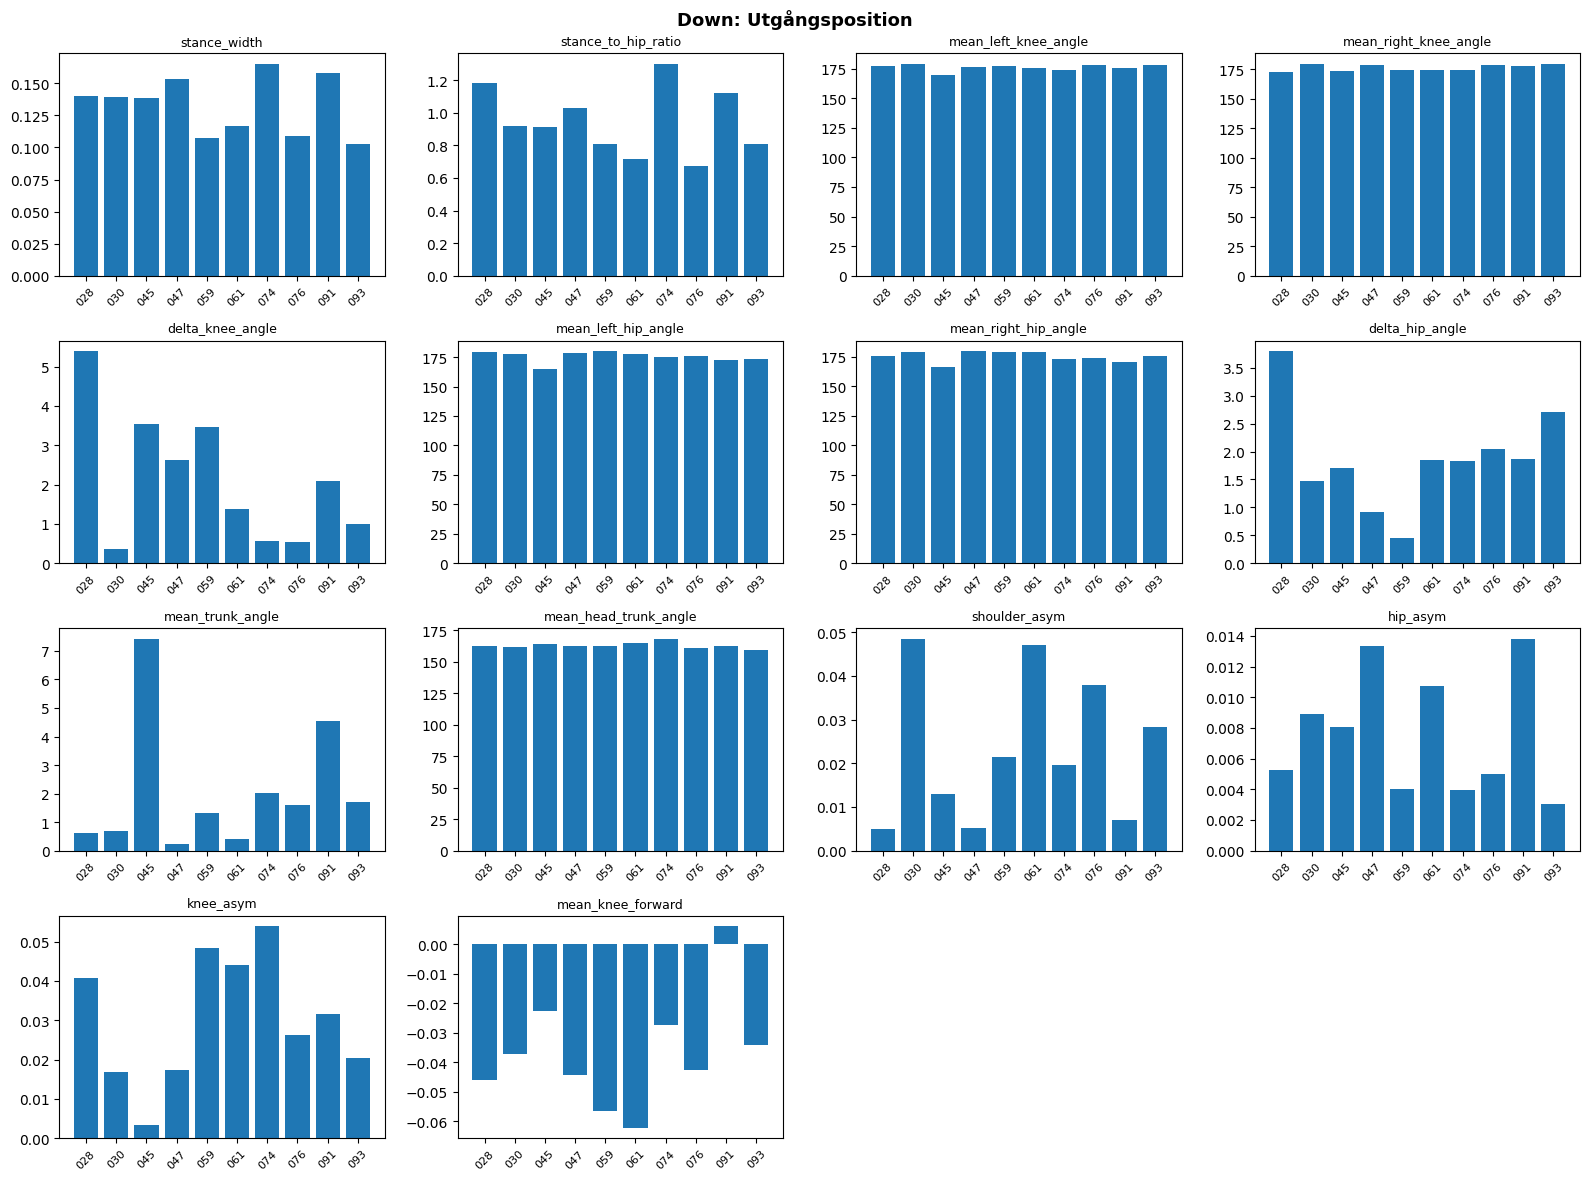

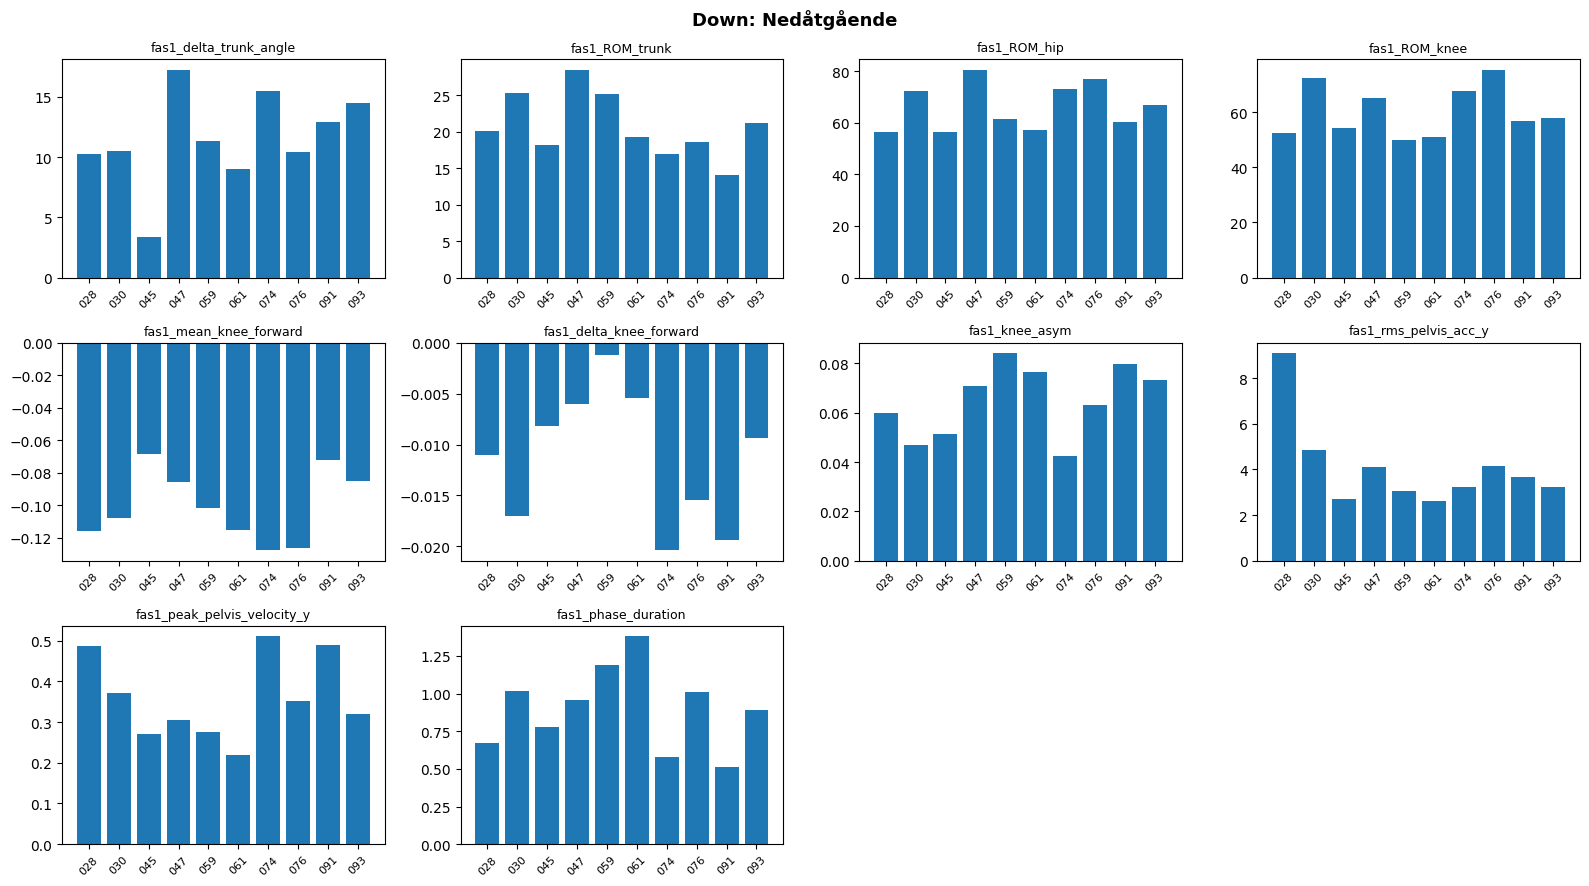

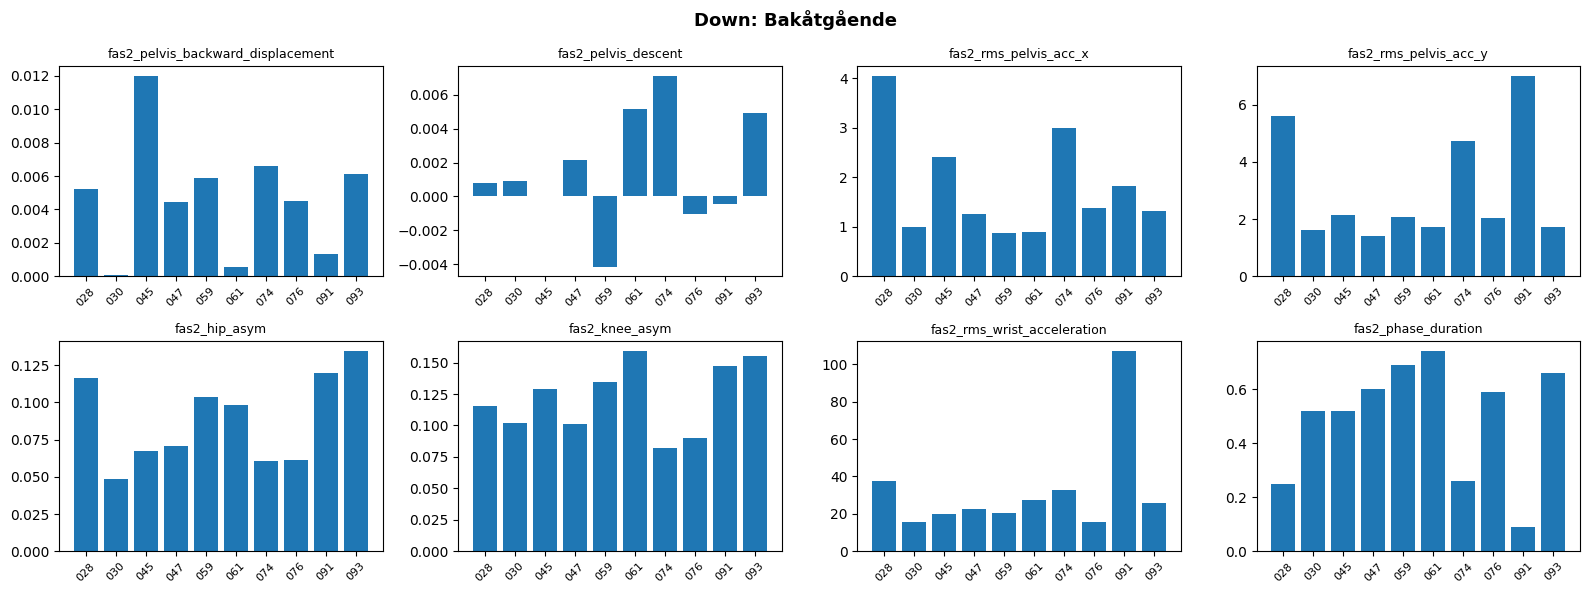

In [33]:
plot_phase(df_down_utgång, 'Down: Utgångsposition', ncols=4, filepath=DOWN_OUT_DIR / 'down_utgångsposition.png')

# Nedåtgående
fas1_cols = [c for c in df_down_ned.columns if c.startswith('fas1_')]
plot_phase(df_down_ned[fas1_cols], 'Down: Nedåtgående', ncols=4, filepath=DOWN_OUT_DIR / 'down_nedåtgående.png')

# Bakåtgående
fas2_cols = [c for c in df_down_bak.columns if c.startswith('fas2_')]
plot_phase(df_down_bak[fas2_cols], 'Down: Bakåtgående', ncols=4, filepath=DOWN_OUT_DIR / 'down_bakåtgående.png')

## MoLab Features

In [34]:
MOLAB_DOWN_DIR = Path('../data/processed/molab_cropped_down')

molab_corrected_down = {}
for vid in DOWN_TIME_DICT:
    cropped   = pd.read_csv(MOLAB_DOWN_DIR / f'0{vid}_molab.csv')
    corrected = cropped.copy()
    corrected[JOINT_ANGLE_COLS] = cropped[JOINT_ANGLE_COLS] + offsets[vid]
    molab_corrected_down[vid] = corrected

In [35]:
def molab_extract_down_utgångsposition(df, t0, t1):
    p = molab_phase(df, t0, t1)
    lk, rk = p['JointAngle/L_knee_X'], p['JointAngle/R_knee_X']
    return {
        'mean_L_knee_flexion':  lk.mean(),
        'mean_R_knee_flexion':  rk.mean(),
        'delta_knee_asymmetry': abs(lk.mean() - rk.mean()),
        'mean_L_hip_flexion':   p['JointAngle/L_hip_X'].mean(),
        'mean_R_hip_flexion':   p['JointAngle/R_hip_X'].mean(),
        'mean_pelvis_tilt':     p['JointAngle/pelvis_X'].mean(),
        'mean_pelvis_lateral':  p['JointAngle/pelvis_Y'].abs().mean(),
        'mean_L_ankle_flexion': p['JointAngle/L_ankle_X'].mean(),
        'mean_R_ankle_flexion': p['JointAngle/R_ankle_X'].mean(),
    }

def molab_extract_down_rörelsestart(df, t1, t4):
    p        = molab_phase(df, t1, t4)
    pelvis_x = p['JointAngle/pelvis_X']
    gyro_x   = p['SegmentGyro/pelvis_X']
    return {
        'ROM_knee':          ((p['JointAngle/L_knee_X'].max() - p['JointAngle/L_knee_X'].min()) +
                               (p['JointAngle/R_knee_X'].max() - p['JointAngle/R_knee_X'].min())) / 2,
        'ROM_hip':           ((p['JointAngle/L_hip_X'].max() - p['JointAngle/L_hip_X'].min()) +
                               (p['JointAngle/R_hip_X'].max() - p['JointAngle/R_hip_X'].min())) / 2,
        'delta_pelvis_tilt': pelvis_x.max() - pelvis_x.min(),
        'peak_pelvis_gyro':  gyro_x.abs().max(),
        'mean_pelvis_gyro':  gyro_x.abs().mean(),
        'rms_pelvis_acc':    rms(p['SegmentAcc/pelvis_Y'].values),
    }

def molab_extract_down_rörelseutförande(df, t2, t3, t4):
    fas1 = molab_phase(df, t2, t3)
    fas2 = molab_phase(df, t3, t4)
    return {
        'fas1_ROM_hip':          ((fas1['JointAngle/L_hip_X'].max() - fas1['JointAngle/L_hip_X'].min()) +
                                   (fas1['JointAngle/R_hip_X'].max() - fas1['JointAngle/R_hip_X'].min())) / 2,
        'fas1_ROM_knee':         ((fas1['JointAngle/L_knee_X'].max() - fas1['JointAngle/L_knee_X'].min()) +
                                   (fas1['JointAngle/R_knee_X'].max() - fas1['JointAngle/R_knee_X'].min())) / 2,
        'fas1_knee_angle_diff':  (fas1['JointAngle/L_knee_X'] - fas1['JointAngle/R_knee_X']).abs().mean(),
        'fas1_rms_pelvis_acc':   rms(fas1['SegmentAcc/pelvis_Y'].values),
        'fas1_peak_shank_gyro':  max(fas1['SegmentGyro/L_shank_X'].abs().max(),
                                     fas1['SegmentGyro/R_shank_X'].abs().max()),
        'fas1_pelvis_lateral':   fas1['JointAngle/pelvis_Y'].abs().mean(),
        'fas1_peak_thigh_gyro':  max(fas1['SegmentGyro/L_thigh_X'].abs().max(),
                                     fas1['SegmentGyro/R_thigh_X'].abs().max()),
        'fas2_pelvis_lateral':   fas2['JointAngle/pelvis_Y'].abs().mean(),
        'fas2_rms_pelvis_acc':   rms(fas2['SegmentAcc/pelvis_Y'].values),
        'fas2_peak_pelvis_gyro': fas2['SegmentGyro/pelvis_X'].abs().max(),
        'fas2_ROM_knee':         ((fas2['JointAngle/L_knee_X'].max() - fas2['JointAngle/L_knee_X'].min()) +
                                   (fas2['JointAngle/R_knee_X'].max() - fas2['JointAngle/R_knee_X'].min())) / 2,
        'fas2_ROM_hip':          ((fas2['JointAngle/L_hip_X'].max() - fas2['JointAngle/L_hip_X'].min()) +
                                   (fas2['JointAngle/R_hip_X'].max() - fas2['JointAngle/R_hip_X'].min())) / 2,
    }

In [36]:
rows_utg, rows_rs, rows_ru = [], [], []

for vid, (t0, t1, t2, t3, t4) in DOWN_TIME_DICT.items():
    df = molab_corrected_down[vid]
    rows_utg.append({'video': vid, **molab_extract_down_utgångsposition(df, t0, t1)})
    rows_rs.append( {'video': vid, **molab_extract_down_rörelsestart(df, t1, t4)})
    rows_ru.append( {'video': vid, **molab_extract_down_rörelseutförande(df, t2, t3, t4)})

df_down_molab_utg = pd.DataFrame(rows_utg).set_index('video')
df_down_molab_rs  = pd.DataFrame(rows_rs).set_index('video')
df_down_molab_ru  = pd.DataFrame(rows_ru).set_index('video')

df_down_molab_utg.to_csv(DOWN_OUT_DIR / 'down_molab_utgångsposition.csv')
df_down_molab_rs.to_csv(DOWN_OUT_DIR  / 'down_molab_rörelsestart.csv')
df_down_molab_ru.to_csv(DOWN_OUT_DIR  / 'down_molab_rörelseutförande.csv')

print("=== Utgångsposition ==="); display(df_down_molab_utg.round(2))
print("=== Rörelsestart ===");    display(df_down_molab_rs.round(2))
print("=== Rörelseutförande ==="); display(df_down_molab_ru.round(4))

=== Utgångsposition ===


,mean_L_knee_flexion,mean_R_knee_flexion,delta_knee_asymmetry,mean_L_hip_flexion,mean_R_hip_flexion,mean_pelvis_tilt,mean_pelvis_lateral,mean_L_ankle_flexion,mean_R_ankle_flexion
video,,,,,,,,,
028,3.57,5.84,2.27,-2.07,2.78,7.86,1.74,65.46,62.94
030,-1.28,2.94,4.23,-5.25,2.78,13.09,2.16,68.64,65.67
045,14.14,10.41,3.73,27.63,30.94,28.43,1.48,73.30,64.64
047,-5.94,-6.58,0.64,-4.54,1.48,19.80,0.66,76.07,69.63
059,-0.94,-5.98,5.04,9.91,10.87,31.40,8.20,72.25,64.32
061,1.81,0.04,1.77,10.19,12.87,31.25,4.21,75.48,70.03
074,10.94,3.66,7.29,21.75,21.40,26.20,3.29,74.41,66.10
076,-5.15,-7.05,1.90,0.17,1.03,24.59,0.94,76.88,70.74
091,-1.20,-3.27,2.07,6.96,12.33,15.45,1.97,57.23,52.56


=== Rörelsestart ===


,ROM_knee,ROM_hip,delta_pelvis_tilt,peak_pelvis_gyro,mean_pelvis_gyro,rms_pelvis_acc
video,,,,,,
028,95.43,91.64,36.68,116.04,65.57,0.72
030,101.47,101.34,35.77,99.88,41.36,0.32
045,73.06,82.77,69.38,483.50,75.90,0.84
047,89.95,110.34,49.75,108.71,59.35,0.38
059,91.94,83.29,38.77,79.37,31.70,0.70
061,90.15,72.68,40.01,101.01,26.62,0.31
074,94.52,98.36,29.16,258.38,53.80,0.81
076,106.44,104.25,34.57,108.32,40.22,0.24
091,88.12,95.62,30.97,122.63,59.51,1.06


=== Rörelseutförande ===


,fas1_ROM_hip,fas1_ROM_knee,fas1_knee_angle_diff,fas1_rms_pelvis_acc,fas1_peak_shank_gyro,fas1_pelvis_lateral,fas1_peak_thigh_gyro,fas2_pelvis_lateral,fas2_rms_pelvis_acc,fas2_peak_pelvis_gyro,fas2_ROM_knee,fas2_ROM_hip
video,,,,,,,,,,,,
028,91.6405,95.1020,2.1902,0.8077,62.513,2.7478,208.973,4.1452,0.4051,78.379,1.6650,10.2110
030,101.3400,99.4285,6.0574,0.3939,52.528,3.0633,143.262,4.7833,0.0890,84.195,2.3355,12.7970
045,82.7730,72.4765,2.0524,0.9110,48.380,0.8680,113.033,0.7263,0.7265,483.498,2.3720,41.5185
047,110.3370,88.4585,2.8550,0.4780,43.476,1.7763,142.506,0.2722,0.1126,91.558,1.8495,24.2135
059,83.2935,91.8645,7.9103,0.8052,24.107,6.1276,121.115,4.4873,0.4541,53.218,0.6995,10.3310
061,72.6760,87.7675,7.0752,0.3744,38.507,2.7431,93.232,2.8263,0.1475,101.006,2.7935,15.5275
074,94.3850,89.8740,8.0900,0.8400,97.647,2.6948,177.313,0.3483,0.7222,67.899,4.6775,4.5130
076,104.2485,104.2040,5.3986,0.2807,53.560,1.4755,120.934,0.7683,0.1339,50.549,2.1025,16.8295
091,95.6190,88.1190,1.8198,1.0861,111.899,1.0155,228.109,2.0350,0.9434,111.864,0.5040,2.1680


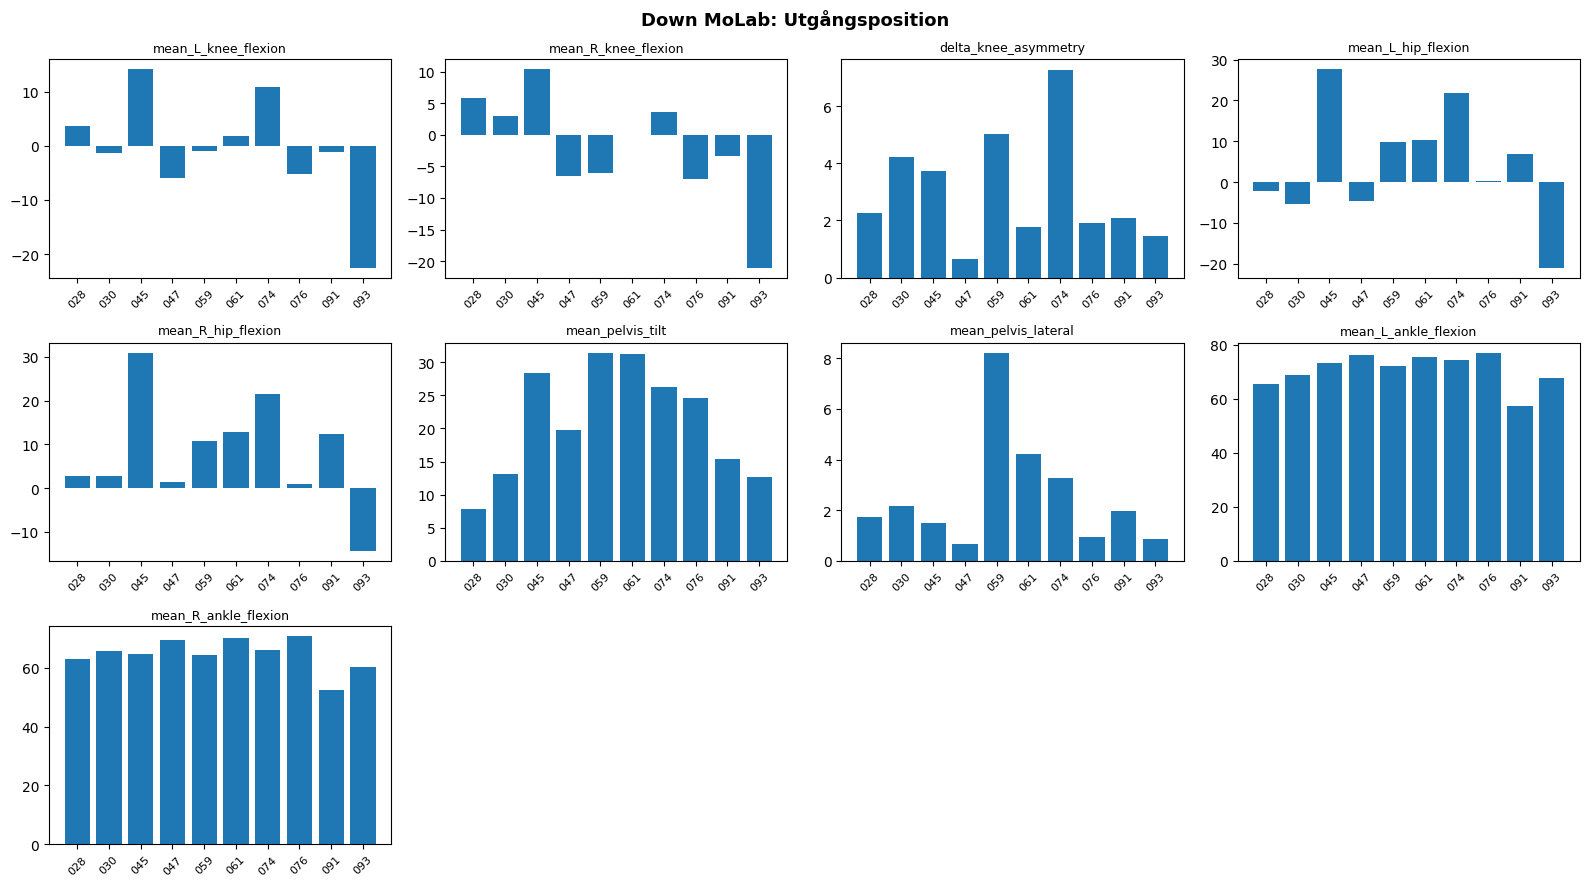

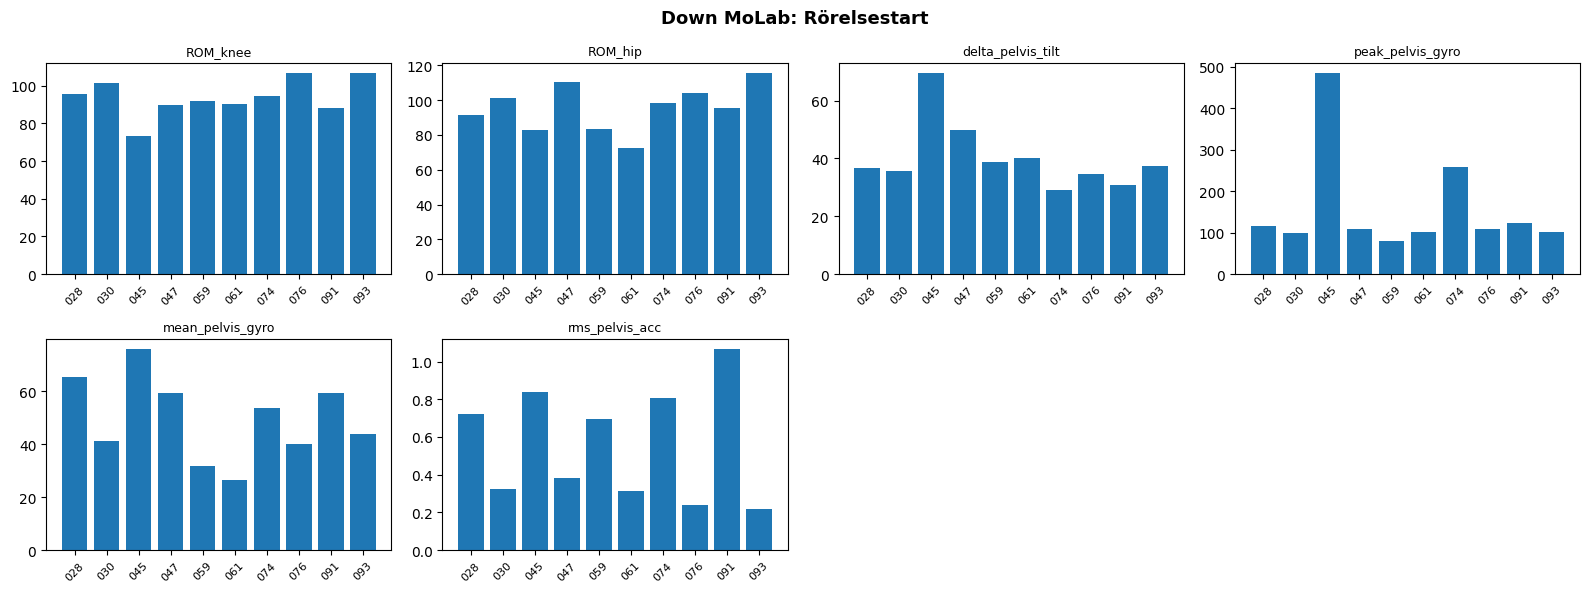

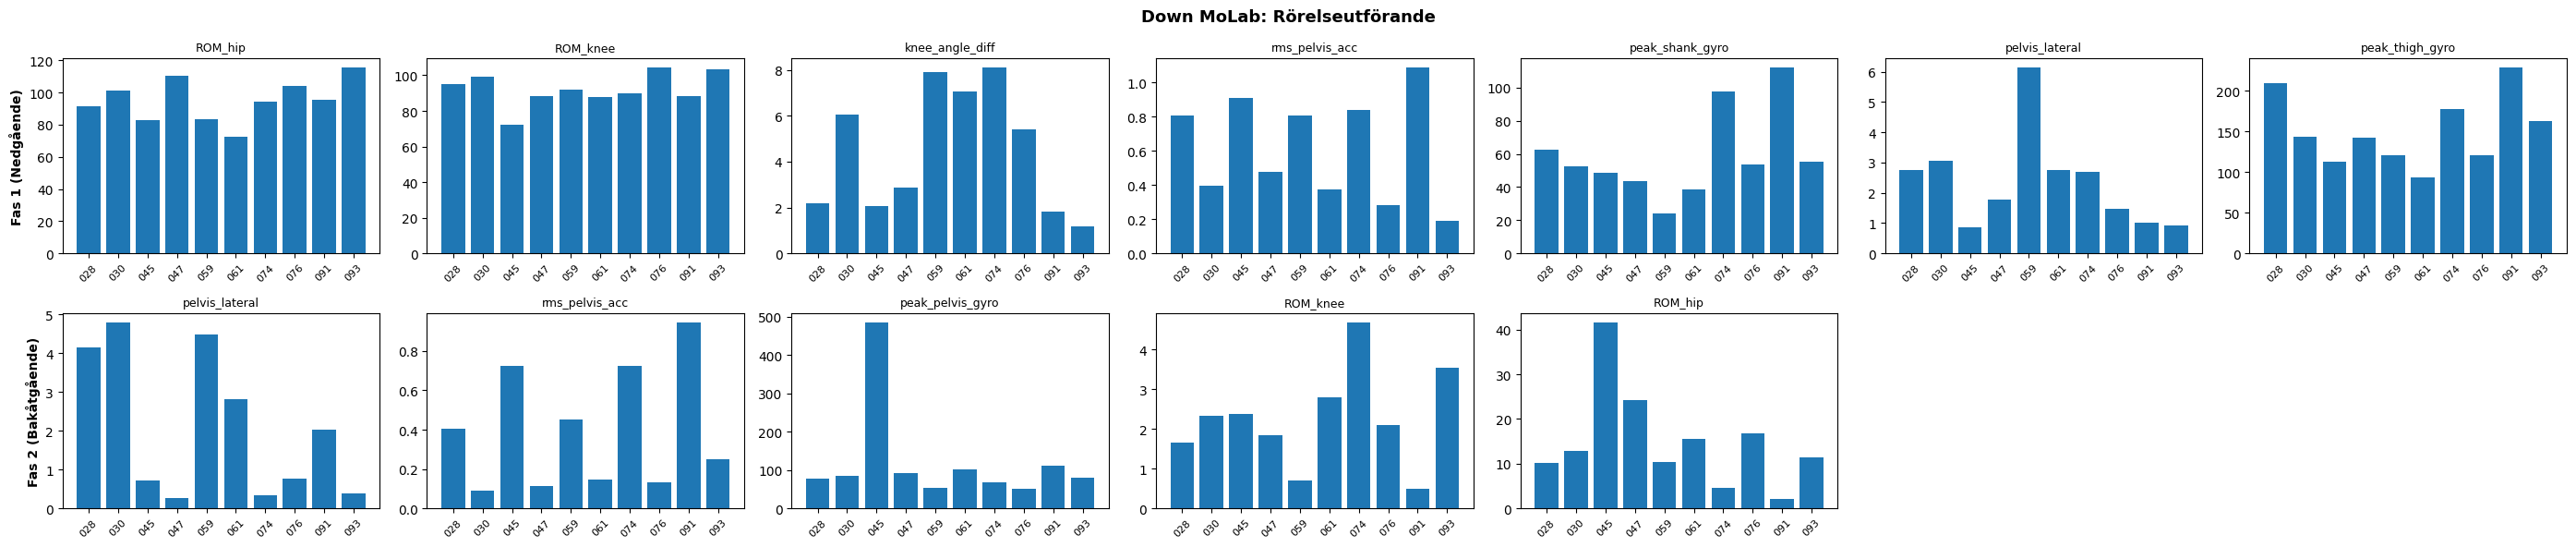

In [37]:
fas1_cols = [c for c in df_down_molab_ru.columns if c.startswith('fas1_')]
fas2_cols = [c for c in df_down_molab_ru.columns if c.startswith('fas2_')]
ncols_ru  = max(len(fas1_cols), len(fas2_cols))

plot_phase(df_down_molab_utg, 'Down MoLab: Utgångsposition', ncols=4, filepath=DOWN_OUT_DIR / 'down_molab_utgångsposition.png')
plot_phase(df_down_molab_rs,  'Down MoLab: Rörelsestart',    ncols=4, filepath=DOWN_OUT_DIR / 'down_molab_rörelsestart.png')

fig, axes = plt.subplots(2, ncols_ru, figsize=(4 * ncols_ru, 6))
for i, feat in enumerate(fas1_cols):
    axes[0, i].bar(df_down_molab_ru.index, df_down_molab_ru[feat])
    axes[0, i].set_title(feat.replace('fas1_', ''), fontsize=9)
    axes[0, i].tick_params(axis='x', rotation=45, labelsize=8)
for i, feat in enumerate(fas2_cols):
    axes[1, i].bar(df_down_molab_ru.index, df_down_molab_ru[feat])
    axes[1, i].set_title(feat.replace('fas2_', ''), fontsize=9)
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=8)
for ax in axes.flatten():
    if not ax.has_data():
        ax.set_visible(False)
axes[0, 0].set_ylabel('Fas 1 (Nedgående)', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Fas 2 (Bakåtgående)', fontsize=10, fontweight='bold')
fig.suptitle('Down MoLab: Rörelseutförande', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(DOWN_OUT_DIR / 'down_molab_rörelseutförande.png', dpi=150)
plt.show()